In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.optim import Optimizer
import torchmetrics

device = "cuda"

In [2]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55000, 5000])

In [3]:
from torch.utils.data import DataLoader

batch_size = 512
num_workers = 4
persistent_workers = True
pin_memory = True

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)
valid_loader = DataLoader(valid_data, batch_size=batch_size, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)
test_loader = DataLoader(test_data, batch_size=batch_size, pin_memory=pin_memory, num_workers=num_workers, persistent_workers=persistent_workers)

Label	Class
0	T-shirt/top
1	Trouser
2	Pullover
3	Dress
4	Coat
5	Sandal
6	Shirt
7	Sneaker
8	Bag
9	Ankle boot

In [4]:
X_sample, y_sample = train_data[0]
X_sample.shape

torch.Size([1, 28, 28])

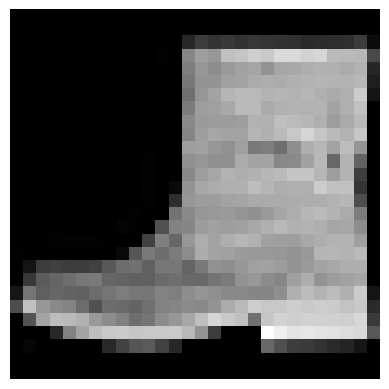

'Ankle boot'

In [5]:
plt.imshow(X_sample.squeeze(), cmap="gray")
plt.axis("off")
plt.show()
train_and_valid_data.classes[y_sample]

In [6]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )
        
    def forward(self, X):
        return self.mlp(X)

In [7]:
def train(model:nn.Module, criterion, optimizer:Optimizer, n_epochs:int, datalodaer:DataLoader):
    model.to(device)
    model.train()
    for i in range(n_epochs):
        total_loss = 0
        for X, y in datalodaer:
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = criterion(y_pred, y)
            loss.backward()
            total_loss += loss
            optimizer.step()

        mean_loss = total_loss/len(datalodaer)
        print(f"epoch:{i}, total_loss:{mean_loss}")

def eval(model:nn.Module, dataloader:DataLoader, metric_fn, aggregate_fn = torch.mean):
    model.to(device)
    model.eval()
    metrics = []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            metric = metric_fn(y_pred, y)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [8]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10)
xentropy = nn.CrossEntropyLoss()
lr = 0.001
n_epochs = 20
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr)

In [9]:
train(model, xentropy, optimizer, n_epochs, train_loader)

epoch:0, total_loss:0.8004028797149658
epoch:1, total_loss:0.46115851402282715
epoch:2, total_loss:0.40378281474113464
epoch:3, total_loss:0.3715795874595642
epoch:4, total_loss:0.34777605533599854
epoch:5, total_loss:0.3298772871494293
epoch:6, total_loss:0.3152447044849396
epoch:7, total_loss:0.3022856116294861
epoch:8, total_loss:0.29430827498435974
epoch:9, total_loss:0.2813374996185303
epoch:10, total_loss:0.2732600271701813
epoch:11, total_loss:0.263168066740036
epoch:12, total_loss:0.2598387598991394
epoch:13, total_loss:0.2526841461658478
epoch:14, total_loss:0.23804648220539093
epoch:15, total_loss:0.2362658679485321
epoch:16, total_loss:0.2360849678516388
epoch:17, total_loss:0.22936603426933289
epoch:18, total_loss:0.22118492424488068
epoch:19, total_loss:0.21209195256233215


In [10]:
print(eval(model, train_loader, accuracy))
print(eval(model, valid_loader, accuracy))

tensor(0.9188, device='cuda:0')
tensor(0.8773, device='cuda:0')


In [11]:
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)

y_pred = y_pred_logits.argmax(dim=1)
y_pred


tensor([7, 4, 2], device='cuda:0')

In [12]:
import torch.nn.functional as F
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.8090, 0.0000,
         0.1900],
        [0.0000, 0.0000, 0.0030, 0.0000, 0.9970, 0.0000, 0.0010, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.7850, 0.0000, 0.1610, 0.0000, 0.0530, 0.0000, 0.0010,
         0.0000]], device='cuda:0')

In [13]:
y_top4_logits, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_logits, dim=1)
y_top4_probas.round(decimals=3)

tensor([[0.8090, 0.1900, 0.0010, 0.0000],
        [0.9970, 0.0030, 0.0010, 0.0000],
        [0.7850, 0.1610, 0.0530, 0.0010]], device='cuda:0')

In [16]:
import optuna

def objective(trial:optuna.Trial):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    n_hidden = trial.suggest_int("n_hidden", 20, 300)
    model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=n_hidden, n_hidden2=n_hidden, n_classes=10).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    train(model, criterion, optimizer, n_epochs, train_loader)
    validation_accuracy = eval(model, valid_loader, accuracy)
    return validation_accuracy

In [17]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-05-23 13:17:05,771] A new study created in memory with name: no-name-1ca257ed-5092-46c8-a5f2-335a63e07963


epoch:0, total_loss:2.3066654205322266
epoch:1, total_loss:2.3025660514831543
epoch:2, total_loss:2.298560380935669
epoch:3, total_loss:2.2944746017456055
epoch:4, total_loss:2.2904953956604004
epoch:5, total_loss:2.286489963531494
epoch:6, total_loss:2.282531261444092
epoch:7, total_loss:2.2785542011260986
epoch:8, total_loss:2.2746424674987793
epoch:9, total_loss:2.270700454711914
epoch:10, total_loss:2.2668204307556152
epoch:11, total_loss:2.2628841400146484
epoch:12, total_loss:2.258913993835449
epoch:13, total_loss:2.2549378871917725
epoch:14, total_loss:2.250964641571045
epoch:15, total_loss:2.246859550476074
epoch:16, total_loss:2.2427632808685303
epoch:17, total_loss:2.2385671138763428
epoch:18, total_loss:2.2343876361846924
epoch:19, total_loss:2.230109930038452


[I 2026-05-23 13:17:42,599] Trial 0 finished with value: 0.22244897484779358 and parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287}. Best is trial 0 with value: 0.22244897484779358.


epoch:0, total_loss:2.272282123565674
epoch:1, total_loss:2.1582541465759277
epoch:2, total_loss:1.9289482831954956
epoch:3, total_loss:1.596733570098877
epoch:4, total_loss:1.3266503810882568
epoch:5, total_loss:1.1532238721847534
epoch:6, total_loss:1.0388444662094116
epoch:7, total_loss:0.9594479203224182
epoch:8, total_loss:0.9005061984062195
epoch:9, total_loss:0.8539497256278992
epoch:10, total_loss:0.8183169960975647
epoch:11, total_loss:0.7874835133552551
epoch:12, total_loss:0.7615246176719666
epoch:13, total_loss:0.7398077845573425
epoch:14, total_loss:0.7201079726219177
epoch:15, total_loss:0.7019612193107605
epoch:16, total_loss:0.6854209303855896
epoch:17, total_loss:0.6698815226554871
epoch:18, total_loss:0.6559146642684937
epoch:19, total_loss:0.6425066590309143


[I 2026-05-23 13:18:28,190] Trial 1 finished with value: 0.7682836651802063 and parameters: {'learning_rate': 0.008471801418819975, 'n_hidden': 188}. Best is trial 1 with value: 0.7682836651802063.


...

[I 2026-05-23 13:19:15,880] Trial 2 finished with value: 0.1115114837884903 and parameters: {'learning_rate': 4.207988669606632e-05, 'n_hidden': 63}. Best is trial 1 with value: 0.7682836651802063.


epoch:0, total_loss:2.3023784160614014
epoch:1, total_loss:2.302189588546753
epoch:2, total_loss:2.3020665645599365
epoch:3, total_loss:2.301874876022339
epoch:4, total_loss:2.3016839027404785
epoch:5, total_loss:2.3015329837799072
epoch:6, total_loss:2.3013298511505127
epoch:7, total_loss:2.3011767864227295
epoch:8, total_loss:2.300981283187866
epoch:9, total_loss:2.3008227348327637
epoch:10, total_loss:2.3006274700164795
epoch:11, total_loss:2.300459146499634
epoch:12, total_loss:2.300278425216675
epoch:13, total_loss:2.300097703933716
epoch:14, total_loss:2.2999002933502197
epoch:15, total_loss:2.2997634410858154
epoch:16, total_loss:2.299567937850952
epoch:17, total_loss:2.2994112968444824
epoch:18, total_loss:2.2992420196533203
epoch:19, total_loss:2.299015522003174


[I 2026-05-23 13:20:03,165] Trial 3 finished with value: 0.09494180977344513 and parameters: {'learning_rate': 1.7073967431528103e-05, 'n_hidden': 263}. Best is trial 1 with value: 0.7682836651802063.


epoch:0, total_loss:2.292379140853882
epoch:1, total_loss:2.2640678882598877
epoch:2, total_loss:2.2330195903778076
epoch:3, total_loss:2.1972200870513916
epoch:4, total_loss:2.154486656188965
epoch:5, total_loss:2.102447032928467
epoch:6, total_loss:2.0383012294769287
epoch:7, total_loss:1.9599720239639282
epoch:8, total_loss:1.8669822216033936
epoch:9, total_loss:1.7624183893203735
epoch:10, total_loss:1.6532926559448242
epoch:11, total_loss:1.5474214553833008
epoch:12, total_loss:1.4521424770355225
epoch:13, total_loss:1.3693184852600098
epoch:14, total_loss:1.2982698678970337
epoch:15, total_loss:1.2373677492141724
epoch:16, total_loss:1.1847119331359863
epoch:17, total_loss:1.138986587524414
epoch:18, total_loss:1.0998730659484863
epoch:19, total_loss:1.0649746656417847


[I 2026-05-23 13:20:50,626] Trial 4 finished with value: 0.6295081377029419 and parameters: {'learning_rate': 0.002537815508265664, 'n_hidden': 218}. Best is trial 1 with value: 0.7682836651802063.


In [18]:
print(study.best_params)
print(study.best_value)

{'learning_rate': 0.008471801418819975, 'n_hidden': 188}
0.7682836651802063
